In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [10]:
# Carregar os dados
df = pd.read_csv("Train_data.csv")

# Separar atributos (X) e alvo (y)
X_raw = df.drop('class', axis=1)
y_raw = df['class']

# 1. Transformar as variáveis categóricas em Dummies 
cat_cols = ['protocol_type', 'service', 'flag']
X_encoded = pd.get_dummies(X_raw, columns=cat_cols)

# 2. Transformar a classe alvo em números numéricos
le = LabelEncoder()
y_encoded = le.fit_transform(y_raw)

# 3. Divisão em Treino e Teste (70% treino, 30% teste)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

# 4. Escalonamento dos dados (Crucial para o KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Dimensões do Treino: {X_train_scaled.shape}")
print(f"Dimensões do Teste: {X_test_scaled.shape}")

Dimensões do Treino: (17634, 118)
Dimensões do Teste: (7558, 118)


In [11]:
# Definir os hiperparâmetros que queremos testar
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'metric': ['euclidean', 'manhattan']
}

print("Busca pelo melhor K e distância.")
start_time = time.time()

# Configurar o Grid Search com validação cruzada 
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=3, scoring='accuracy', n_jobs=-1)

# Treinar o Grid Search
grid_search.fit(X_train_scaled, y_train)

end_time = time.time()

print(f"Tempo de busca: {end_time - start_time:.2f} segundos")
print(f"Melhores parâmetros encontrados: {grid_search.best_params_}")
print(f"Melhor Acurácia na Validação Cruzada: {grid_search.best_score_:.4%}")

Busca pelo melhor K e distância.
Tempo de busca: 21.09 segundos
Melhores parâmetros encontrados: {'metric': 'manhattan', 'n_neighbors': 3}
Melhor Acurácia na Validação Cruzada: 99.3989%


--- Treinamento Final com os Melhores Parâmetros ---
Tempo de inferência (teste): 1.5800 segundos
Acurácia no Teste: 99.4311%

Relatório de Classificação:
              precision    recall  f1-score   support

     anomaly       1.00      0.99      0.99      3523
      normal       0.99      1.00      0.99      4035

    accuracy                           0.99      7558
   macro avg       0.99      0.99      0.99      7558
weighted avg       0.99      0.99      0.99      7558



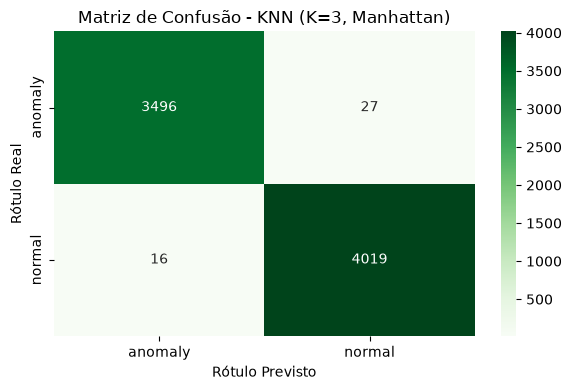

In [12]:
print("--- Treinamento Final com os Melhores Parâmetros ---")
# O scikit-learn já guarda o melhor modelo treinado dentro do grid_search
melhor_knn = grid_search.best_estimator_

# Previsão no conjunto de teste (os 30% separados na Célula 2)
start_time_test = time.time()
y_pred = melhor_knn.predict(X_test_scaled)
end_time_test = time.time()

acc_final = accuracy_score(y_test, y_pred)
print(f"Tempo de inferência (teste): {end_time_test - start_time_test:.4f} segundos")
print(f"Acurácia no Teste: {acc_final:.4%}\n")

print("Relatório de Classificação:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de Confusão - KNN (K=3, Manhattan)')
plt.xlabel('Rótulo Previsto')
plt.ylabel('Rótulo Real')
plt.tight_layout()
plt.show()

In [8]:
print("--- TESTE DE RESILIÊNCIA: Simulando a perda de 'src_bytes' ---")

# 1. Encontrar o índice exato da coluna 'src_bytes' nos dados originais
coluna_alvo = 'src_bytes'
idx_src = list(X_train.columns).index(coluna_alvo)

# 2. Remover a coluna de forma cirúrgica dos arrays escalonados
X_train_resiliente = np.delete(X_train_scaled, idx_src, axis=1)
X_test_resiliente = np.delete(X_test_scaled, idx_src, axis=1)

print(f"Dimensões APÓS remover a feature:")
print(f"Treino: {X_train_resiliente.shape} | Teste: {X_test_resiliente.shape}\n")

# 3. Retreinar o modelo com a configuração vencedora para ser uma comparação justa
knn_resiliente = KNeighborsClassifier(n_neighbors=3, metric='manhattan')
knn_resiliente.fit(X_train_resiliente, y_train)

# 4. Prever e avaliar o impacto
y_pred_resiliente = knn_resiliente.predict(X_test_resiliente)
acc_resiliente = accuracy_score(y_test, y_pred_resiliente)

print("--- RESULTADOS DO IMPACTO ---")
print(f"Acurácia Original (Com {coluna_alvo}): {acc_final:.4%}")
print(f"Acurácia Resiliente (Sem {coluna_alvo}): {acc_resiliente:.4%}")
print(f"Queda Absoluta na Acurácia: {(acc_final - acc_resiliente):.4%}")

--- TESTE DE RESILIÊNCIA: Simulando a perda de 'src_bytes' ---
Dimensões APÓS remover a feature:
Treino: (17634, 117) | Teste: (7558, 117)

--- RESULTADOS DO IMPACTO ---
Acurácia Original (Com src_bytes): 99.4311%
Acurácia Resiliente (Sem src_bytes): 99.4311%
Queda Absoluta na Acurácia: 0.0000%
